In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

In [2]:
#Load dataseet

fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()



29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print(train_images.shape)
print(test_images.shape)

print(train_labels)


(60000, 28, 28)
(10000, 28, 28)
[9 0 0 ... 3 0 5]


In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [5]:
train_images = train_images / 255.0

test_images = test_images / 255.0

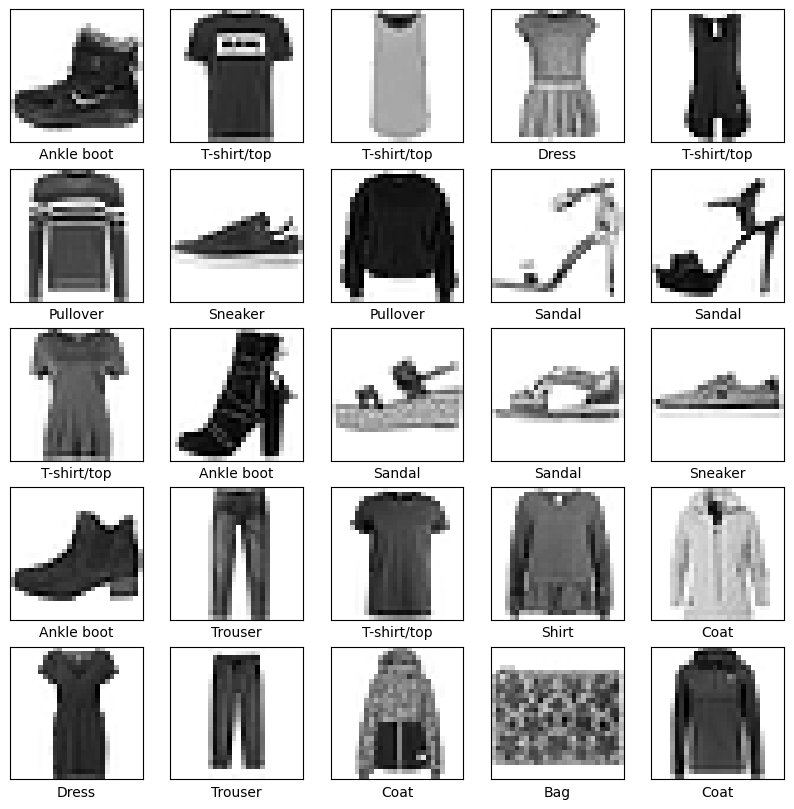

In [6]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [7]:
# Build neural network

model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])


In [8]:
# Compile Model
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [9]:
# Train Model

history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)



Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8065 - loss: 0.5475 - val_accuracy: 0.8443 - val_loss: 0.4335
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8527 - loss: 0.4061 - val_accuracy: 0.8590 - val_loss: 0.3835
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8629 - loss: 0.3737 - val_accuracy: 0.8602 - val_loss: 0.3792
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8710 - loss: 0.3516 - val_accuracy: 0.8767 - val_loss: 0.3417
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8769 - loss: 0.3370 - val_accuracy: 0.8718 - val_loss: 0.3513
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8808 - loss: 0.3220 - val_accuracy: 0.8833 - val_loss: 0.3266
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8845 - loss: 0.3103 - val_accuracy: 0.8861 - val_loss: 0.3195
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8870 - loss: 0.3008 - 

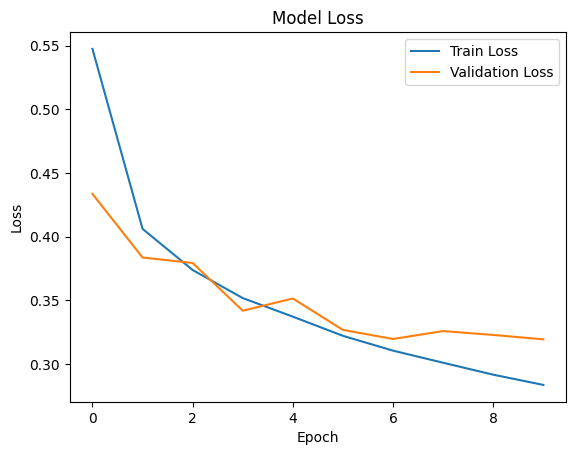

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train Loss', 'Validation Loss'])

plt.show()


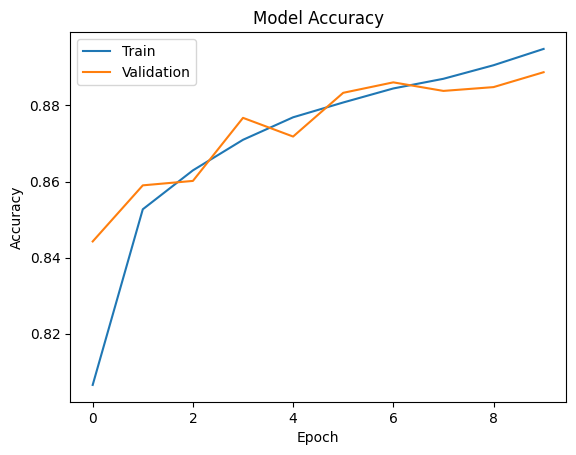

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train', 'Validation'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()


In [12]:
# Validation 

test_loss, test_acc = model.evaluate(
    test_images,
    test_labels
)

print("Test accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - accuracy: 0.8764 - loss: 0.3451
Test accuracy: 0.8763999938964844


In [13]:
# Testar med SGD optimizer

# Skapa en Ny modell (viktigt för rätt jämförelse)
model_sgd = Sequential([
    Input(shape=(28, 28)),     # Input = 28x28 bild
    Flatten(),                 # Gör om bilden till en vektor
    Dense(128, activation='relu'),  # Dold lager
    Dropout(0.2),             # Regularisering (minskar overfitting)
    Dense(10, activation='softmax') # Output (10 klasser)
])

# SGD optimizer (utan momentum)
optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01
)

# Kompilera modellen
model_sgd.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Träna modellen
history_sgd = model_sgd.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

# Utvärdera på testdata
test_loss_sgd, test_acc_sgd = model_sgd.evaluate(test_images, test_labels)

print("SGD Test accuracy:", test_acc_sgd)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7122 - loss: 0.8653 - val_accuracy: 0.8044 - val_loss: 0.5925
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8001 - loss: 0.5881 - val_accuracy: 0.8209 - val_loss: 0.5146
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8214 - loss: 0.5231 - val_accuracy: 0.8324 - val_loss: 0.4844
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8309 - loss: 0.4897 - val_accuracy: 0.8408 - val_loss: 0.4559
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8393 - loss: 0.4634 - val_accuracy: 0.8462 - val_loss: 0.4361
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8450 - loss: 0.4448 - val_accuracy: 0.8512 - val_loss: 0.4262
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8505 - loss: 0.4310 - val_accuracy: 0.8485 - val_loss: 0.4252
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8541 - loss: 0.4180 - 

In [14]:
model_sgd_low = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.001
)

model_sgd_low.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd_low = model_sgd_low.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

test_loss_sgd_low, test_acc_sgd_low = model_sgd_low.evaluate(test_images, test_labels)

print("SGD (low LR) Test accuracy:", test_acc_sgd_low)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5159 - loss: 1.5455 - val_accuracy: 0.6737 - val_loss: 1.1129
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.6587 - loss: 1.0455 - val_accuracy: 0.7213 - val_loss: 0.8816
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7015 - loss: 0.8921 - val_accuracy: 0.7446 - val_loss: 0.7833
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7256 - loss: 0.8149 - val_accuracy: 0.7619 - val_loss: 0.7277
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7432 - loss: 0.7639 - val_accuracy: 0.7732 - val_loss: 0.6884
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7552 - loss: 0.7261 - val_accuracy: 0.7823 - val_loss: 0.6582
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7659 - loss: 0.6971 - val_accuracy: 0.7906 - val_loss: 0.6353
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7739 - loss: 0.6738 - 

In [15]:
model_sgd_m = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.SGD(
    learning_rate=0.01,
    momentum=0.9
)

model_sgd_m.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd_m = model_sgd_m.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2
)

test_loss_sgd_m, test_acc_sgd_m = model_sgd_m.evaluate(test_images, test_labels)

print("SGD + Momentum Test accuracy:", test_acc_sgd_m)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7919 - loss: 0.5833 - val_accuracy: 0.8363 - val_loss: 0.4536
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8414 - loss: 0.4381 - val_accuracy: 0.8557 - val_loss: 0.4022
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8542 - loss: 0.4035 - val_accuracy: 0.8672 - val_loss: 0.3673
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8625 - loss: 0.3801 - val_accuracy: 0.8705 - val_loss: 0.3558
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8664 - loss: 0.3643 - val_accuracy: 0.8692 - val_loss: 0.3572
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8755 - loss: 0.3454 - val_accuracy: 0.8637 - val_loss: 0.3671
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8779 - loss: 0.3359 - val_accuracy: 0.8780 - val_loss: 0.3410
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8796 - loss: 0.3273 - 

In [16]:
# Jämförelse av alla modeller

print("Adam:", test_acc)
print("SGD:", test_acc_sgd)
print("SGD (low LR):", test_acc_sgd_low)
print("SGD + Momentum:", test_acc_sgd_m)

Adam: 0.8763999938964844
SGD: 0.8508999943733215
SGD (low LR): 0.7932999730110168
SGD + Momentum: 0.871999979019165
